In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import raytrace as rt
import numpy as np
import math
from PIL import Image
from pylab import *
from raytrace import implane
import rtcore

/home/hp/miniconda3/envs/py27/lib/python2.7/site-packages/pyfits/__init__.py:22: PyFITSDeprecationWarning: PyFITS is deprecated, please use astropy.io.fits
  PyFITSDeprecationWarning)  # noqa


In [2]:
freq_hz = 15.e6 # Hz, radio wave frequency
grid=(201,201)
rect=(-1.5, -1.5, 1.5, 1.5)
obs=(215, 0, 0)  # Position of the observer (the earth's coordinates) in SGI system
rsph = 10  # Radius of the integrarion sphere
niter = 1500  #The maximum iterations to perform using the algorithm

In [3]:
test1 = rt.implane(grid,
                   rect,
                   obs,
                   rsph,
                   freq=freq_hz,
                   mode='TbrIQUV',
                   trkparms=['pos'],
                   trknpmax=1500)

test1.package = '/home/hp/raytrace/py_raytr_threaded'

plf_cname =  plasma_parameters.c
fname =  plasma_parameters.c
dname =  /home/hp/raytrace_work/raytrace_scripts
bfname =  plasma_parameters.c
name =  plasma_parameters
gcc -g -fPIC  -I/home/hp/miniconda3/envs/py27/lib/python2.7/site-packages/raytrace/inc -c /home/hp/raytrace_work/raytrace_scripts/streamer.c -o streamer.o
gcc -g -fPIC  -I/home/hp/miniconda3/envs/py27/lib/python2.7/site-packages/raytrace/inc -c plasma_parameters.c -o plasma_parameters.o
gcc -shared streamer.o plasma_parameters.o -L/home/hp/miniconda3/envs/py27/lib/python2.7/site-packages/raytrace/lib -L/usr/lib -lm -lmxv -o plasma_parameters.so


In [4]:
grid = (201,201)
nx = int(grid[0])
ny = int(grid[1])

# spacing between tracked rays
stepx = nx // 4   # 25
stepy = ny // 4   # 25

# build evenly spaced tracker rays
trkrays = []

for i in range(0, nx, stepx):
    for j in range(0, ny, stepy):
        trkrays.append([i, j])

print(trkrays)

[[0, 0], [0, 50], [0, 100], [0, 150], [0, 200], [50, 0], [50, 50], [50, 100], [50, 150], [50, 200], [100, 0], [100, 50], [100, 100], [100, 150], [100, 200], [150, 0], [150, 50], [150, 100], [150, 150], [150, 200], [200, 0], [200, 50], [200, 100], [200, 150], [200, 200]]


In [5]:
test1.trace(niter, trkrays)
traj = test1.traj.pos

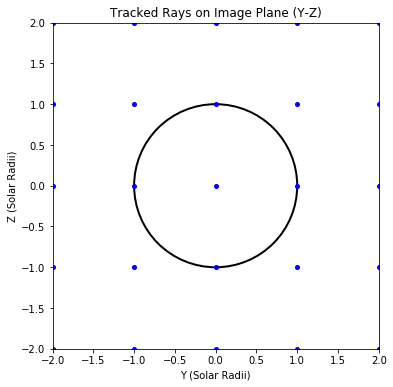

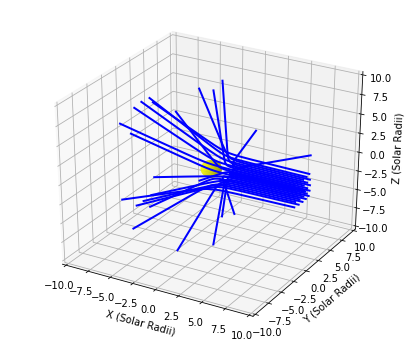

In [10]:
# --------------------------------------------------
# OUTPUT DIRECTORIES
# --------------------------------------------------
OUT_DIR = "/home/hp/raytrace_work/raytrace_results/Ray_Trajectories_15MHz"

if not os.path.exists(OUT_DIR):
    os.makedirs(OUT_DIR)


# Solar radii limits (Y and Z)
ymin, ymax = -2.0, 2.0
zmin, zmax = -2.0, 2.0

# Y and Z coordinates
y = np.linspace(ymin, ymax, nx)
z = np.linspace(zmin, zmax, ny)


# ---------------------------------------------------
# 2D IMAGE PLANE PLOT (Y-Z)
# ---------------------------------------------------
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)


# Sun disk (radius = 1 solar radii)
sun = plt.Circle((0.0, 0.0), 1.0, fill=False, linewidth=2)
ax.add_patch(sun)

# mark tracked rays
for ray in trkrays:
    iy = ray[0]
    iz = ray[1]

    yr = y[iy]
    zr = z[iz]

    ax.plot(yr, zr, 'o', markersize=4, color='blue')

ax.set_xlim(ymin, ymax)
ax.set_ylim(zmin, zmax)
ax.set_aspect('equal')

ax.set_xlabel('Y (Solar Radii)')
ax.set_ylabel('Z (Solar Radii)')
ax.set_title('Tracked Rays on Image Plane (Y-Z)')

plt.savefig(os.path.join(OUT_DIR, "Tracked_Rays_on_Image_Plane.png"),
            dpi=300,
            bbox_inches='tight')
plt.show()

# ---------------------------------------------------
# 3D RAY TRAJECTORIES
# traj assumed shape = (Nrays, Nsteps, 3)
# traj[:,:,0] = X , traj[:,:,1] = Y , traj[:,:,2] = Z
# ---------------------------------------------------
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

# ── Sun sphere at origin, radius = 1 ──────────────────
u = np.linspace(0, 2 * np.pi, 60)
v = np.linspace(0, np.pi, 30)
xs = np.outer(np.cos(u), np.sin(v))   # shape (60, 30)
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(xs, ys, zs,
                color='yellow',
                alpha=0.9,
                rstride=1, cstride=1,
                linewidth=0,
                antialiased=True,
                zorder=1)


for i in range(traj.shape[0]):
    ax.plot(traj[i,:,0],   # X direction (propagation)
            traj[i,:,1],   # Y
            traj[i,:,2],   # Z
            linewidth=2,
            color='blue',
            label='Ray %d' % (i+1))

ax.set_xlabel('X (Solar Radii)')
ax.set_ylabel('Y (Solar Radii)')
ax.set_zlabel('Z (Solar Radii)')

# consistent limits
ax.set_xlim(-10,10)
ax.set_ylim(-10,10)
ax.set_zlim(-10,10)

plt.savefig(os.path.join(OUT_DIR, "Ray_Trajectory_3d.png"),
            dpi=300,
            bbox_inches='tight')
plt.show()


In [ ]:
Nrays, Nsteps = traj.shape[0], traj.shape[1]
print("Trajectory shape:", traj.shape)
 
# ─────────────────────────────────────────────
# OUTPUT DIRECTORIES
# ─────────────────────────────────────────────
FRAMES_DIR = os.path.join(OUT_DIR, "frames")
GIF_PATH   = os.path.join(OUT_DIR, "Ray_Trajectory_3d.gif")
 
# os.makedirs does NOT support exist_ok in Python 2.7
if not os.path.exists(FRAMES_DIR):
    os.makedirs(FRAMES_DIR)
 
# ─────────────────────────────────────────────
# FIXED AXIS LIMITS
# ─────────────────────────────────────────────
XLIM = (-10, 10)
YLIM = (-10, 10)
ZLIM = (-10, 10)
 
# ─────────────────────────────────────────────
# SUN SPHERE GEOMETRY  (computed once)
# ─────────────────────────────────────────────
u  = np.linspace(0, 2.0 * np.pi, 40)
v  = np.linspace(0, np.pi, 20)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))
 
# ─────────────────────────────────────────────
# STEP SELECTION
# step_stride=1  → render all 1500 frames
# step_stride=5  → render 300 frames (quick preview)
# ─────────────────────────────────────────────
step_stride     = 1
steps_to_render = range(1, Nsteps + 1, step_stride)
 
# ─────────────────────────────────────────────
# RAY COLOURS  (one colour per ray)
# ─────────────────────────────────────────────
ray_colors = plt.cm.plasma(np.linspace(0.15, 0.85, Nrays))
 
# ─────────────────────────────────────────────
# RENDER FRAMES
# ─────────────────────────────────────────────
frame_paths = []
total = len(steps_to_render)
 
for idx, step in enumerate(steps_to_render):
 
    # ---- simple progress indicator (no tqdm in py2 by default) ----
    if idx % 50 == 0 or idx == total - 1:
        pct = 100.0 * (idx + 1) / total
        sys.stdout.write("\rRendering frame %d / %d  (%.1f%%)" % (idx + 1, total, pct))
        sys.stdout.flush()
 
    fig = plt.figure(figsize=(7, 6), facecolor='black')
    ax  = fig.add_subplot(111, projection='3d')
    try:
        ax.set_facecolor('black')           # newer matplotlib
    except AttributeError:
        try:
            ax.set_axis_bgcolor('black')    # older matplotlib
        except AttributeError:
            pass                            # silently ignore if neither exists
    fig.patch.set_facecolor('black')
 
    # ── Sun sphere ───────────────────────────
    ax.plot_surface(
        xs, ys, zs,
        color       = 'yellow',
        alpha       = 0.85,
        rstride     = 1,
        cstride     = 1,
        linewidth   = 0,
        antialiased = True,
    )
 
    # ── Ray trajectories up to current step ─
    for i in range(Nrays):
        seg = traj[i, :step, :]         # grow ray up to this step
        if seg.shape[0] < 2:
            continue
        ax.plot(
            seg[:, 0],                  # X (propagation direction)
            seg[:, 1],                  # Y
            seg[:, 2],                  # Z
            linewidth = 1.2,
            color     = ray_colors[i],
            alpha     = 0.45,           # semi-transparent ray line
        )
        # Bright dot at the current ray tip
        ax.scatter(
            seg[-1, 0], seg[-1, 1], seg[-1, 2],
            c      = [ray_colors[i]],
            s      = 6,
            alpha  = 0.8,
            zorder = 5,
        )
 
    # ── Axis limits ──────────────────────────
    ax.set_xlim(XLIM[0], XLIM[1])
    ax.set_ylim(YLIM[0], YLIM[1])
    ax.set_zlim(ZLIM[0], ZLIM[1])
 
    # ── Labels (white text) ──────────────────
    ax.set_xlabel('X (Solar Radii)', color='white', fontsize=9, labelpad=6)
    ax.set_ylabel('Y (Solar Radii)', color='white', fontsize=9, labelpad=6)
    ax.set_zlabel('Z (Solar Radii)', color='white', fontsize=9, labelpad=6)
    ax.tick_params(colors='white', labelsize=7)
 
    for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        pane.fill = False
        pane.set_edgecolor('gray')
 
    # Title: use old-style % formatting (no f-strings in py2)
    ax.set_title(
        'Ray Trajectories - Step %04d / %d' % (step, Nsteps),
        color    = 'white',
        fontsize = 10,
    )
 
    # Fixed camera angle for smooth animation
    ax.view_init(elev=25, azim=45)
 
    # ── Save PNG frame ───────────────────────
    fname = os.path.join(FRAMES_DIR, 'frame_%05d.png' % step)
    plt.savefig(fname, dpi=100, bbox_inches='tight', facecolor='black')
    plt.close(fig)
    frame_paths.append(fname)
 
print("\n%d frames saved to %s" % (len(frame_paths), FRAMES_DIR))
 
# ─────────────────────────────────────────────
# STITCH FRAMES INTO GIF USING PILLOW
# fps=15 → 1500 frames ≈ 100 s animation
# duration is in milliseconds per frame
# ─────────────────────────────────────────────
FPS      = 15
DURATION = int(1000.0 / FPS)           # ms per frame  (≈ 67 ms)
 
print("Building GIF at %d fps -> %s" % (FPS, GIF_PATH))
 
pil_frames = []
total = len(frame_paths)
 
for idx, fpath in enumerate(frame_paths):
    if idx % 100 == 0 or idx == total - 1:
        pct = 100.0 * (idx + 1) / total
        sys.stdout.write("\rLoading frame %d / %d  (%.1f%%)" % (idx + 1, total, pct))
        sys.stdout.flush()
    img = Image.open(fpath).convert('RGB')  # GIF uses palette mode; RGB first
    pil_frames.append(img)
 
print("\nWriting GIF ...")
 
# Pillow's save() writes the animated GIF in one call
pil_frames[0].save(
    GIF_PATH,
    format       = 'GIF',
    save_all     = True,
    append_images= pil_frames[1:],
    duration     = DURATION,
    loop         = 0,               # 0 = loop forever
    optimize     = False,           # True can distort colours; keep False
)
 
print("Done! GIF saved to: %s" % GIF_PATH)

('Trajectory shape:', (25, 1000, 3))
Rendering frame 1000 / 1000  (100.0%)
1000 frames saved to /home/hp/raytrace_work/raytrace_results/Ray_Trajectories_15MHz/frames
Building GIF at 15 fps -> /home/hp/raytrace_work/raytrace_results/Ray_Trajectories_15MHz/Ray_Trajectory_3d.gif
Loading frame 1000 / 1000  (100.0%)
Writing GIF ...
Done! GIF saved to: /home/hp/raytrace_work/raytrace_results/Ray_Trajectories_15MHz/Ray_Trajectory_3d.gif
